# Model Training

## Objective

The objective of this notebook is to train multiple Machine Learning models using the processed dataset.

Instead of selecting a model directly, we will train different classification algorithms, compare their performance, and identify the best model for predicting the recommended hospital department.

The best-performing model will be saved for future deployment.

Artifacts Used

- X_train
- X_test
- y_train
- y_test

In [39]:
import warnings
warnings.filterwarnings("ignore")

In [40]:
import joblib
import pandas as pd

In [41]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

In [42]:
X_train = joblib.load("../artifacts/X_train.pkl")
X_test = joblib.load("../artifacts/X_test.pkl")
y_train = joblib.load("../artifacts/y_train.pkl")
y_test = joblib.load("../artifacts/y_test.pkl")

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((8000, 5000), (2000, 5000), (8000,), (2000,))

## Training Function

In [43]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
results = []
def train_and_evaluate(model, model_name):

    # Train Model
    model.fit(X_train, y_train)

    # Prediction
    y_pred = model.predict(X_test)

    # Evaluation Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="weighted")
    recall = recall_score(y_test, y_pred, average="weighted")
    f1 = f1_score(y_test, y_pred, average="weighted")
    # Store Results
    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

    print(f"{model_name} trained successfully.")

    return model

In [44]:
naive_bayes = train_and_evaluate(model=MultinomialNB(), model_name="Multinomial Naive Bayes")
log_reg = train_and_evaluate(model=LogisticRegression(random_state=42), model_name="Logistic Regression")
linear_svm = train_and_evaluate(model=LinearSVC(random_state=42), model_name="Linear SVM")
random_forest = train_and_evaluate(model=RandomForestClassifier(random_state=42), model_name="Random Forest")

Multinomial Naive Bayes trained successfully.
Logistic Regression trained successfully.
Linear SVM trained successfully.
Random Forest trained successfully.


In [45]:
results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Multinomial Naive Bayes,0.7640,0.765709,0.7640,0.753232
1,Logistic Regression,0.7760,0.760385,0.7760,0.762341
2,Linear SVM,0.7845,0.771075,0.7845,0.770040
3,Random Forest,0.7670,0.753246,0.7670,0.755822


In [46]:
results_df = results_df.sort_values(by="Accuracy", ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Linear SVM,0.7845,0.771075,0.7845,0.770040
1,Logistic Regression,0.7760,0.760385,0.7760,0.762341
2,Random Forest,0.7670,0.753246,0.7670,0.755822
3,Multinomial Naive Bayes,0.7640,0.765709,0.7640,0.753232


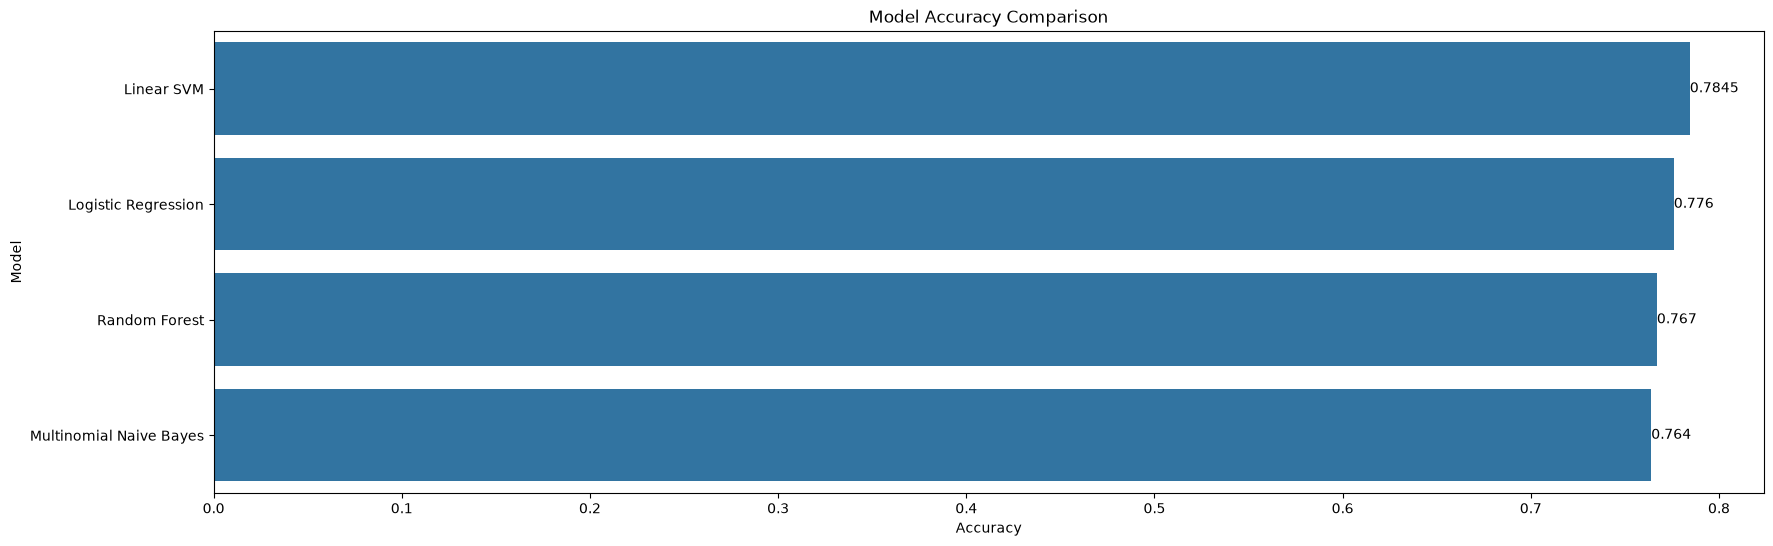

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(20,6))

ax = sns.barplot(data=results_df, x="Accuracy", y="Model")

for container in ax.containers:
    ax.bar_label(container)

plt.title("Model Accuracy Comparison")
plt.xlabel("Accuracy")
plt.ylabel("Model")

plt.show()

In [50]:
best_model = results_df.iloc[0]
best_model

Model        Linear SVM
Accuracy         0.7845
Precision      0.771075
Recall           0.7845
F1 Score        0.77004
Name: 0, dtype: object

In [51]:
best_model_name = best_model["Model"]

models = {
    "Multinomial Naive Bayes": naive_bayes,
    "Logistic Regression": log_reg,
    "Linear SVM": linear_svm,
    "Random Forest": random_forest
}

joblib.dump(
    models[best_model_name],
    "../artifacts/best_model.pkl"
)

print("Best model saved successfully.")

Best model saved successfully.
